Import Library

In [35]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


Defining Parameters

In [36]:
Alpha = 0.1
Gamma = 0.99
Episodes = 500
MAX_STEPS = 200

Epsilon Greedy

In [37]:
def choose_action(q_table,state,epsilon,action_space):
  if np.random.rand()< epsilon:
    return action_space.sample()
  else :
    return np.argmax(q_table[state])

Training

In [38]:
def training_agent(strategy ='high'):

  env = gym.make("CliffWalking-v1")
  state_space = env.observation_space.n
  action_space = env.action_space.n

  q_table = np.zeros((state_space, action_space))
  rewards_per_episode = []
  epsilon = 1.0

  for episode in range(Episodes):
    state ,info = env.reset()
    total_reward = 0

    #Epsilon strategies
    if strategy == "high":
            epsilon = 0.5

    elif strategy == "low":
            epsilon = 0.1

    elif strategy == "decay":
            epsilon = max(0.01, epsilon * 0.995)


    #Episode loop
    for step in range(MAX_STEPS):

      action = choose_action(q_table,state,epsilon,env.action_space)

      next_state,reward,terminated,truncated,info = env.step(action)

      done = terminated or truncated

      #Updating Q-Table
      best_next_action = np.max(q_table[next_state])

      q_table[state, action] = q_table[state, action] + Alpha * (reward+ Gamma * best_next_action- q_table[state, action])


      state = next_state

      total_reward += reward

      if done:
        break

      rewards_per_episode.append(total_reward)

  env.close()

  return rewards_per_episode


MOVING AVERAGE FUNCTION

In [39]:
def moving_average(data, window_size=20):
    return np.convolve(
        data,
        np.ones(window_size) / window_size,
        mode='valid'
    )

TRAIN ALL AGENTS

In [40]:
print("Training High Exploration Agent...")
rewards_high = training_agent("high")

print("Training Low Exploration Agent...")
rewards_low = training_agent("low")

print("Training Decaying Exploration Agent...")
rewards_decay = training_agent("decay")


Training High Exploration Agent...
Training Low Exploration Agent...
Training Decaying Exploration Agent...


SMOOTH REWARDS

In [41]:
smooth_high = moving_average(rewards_high)
smooth_low = moving_average(rewards_low)
smooth_decay = moving_average(rewards_decay)


PLOTTING

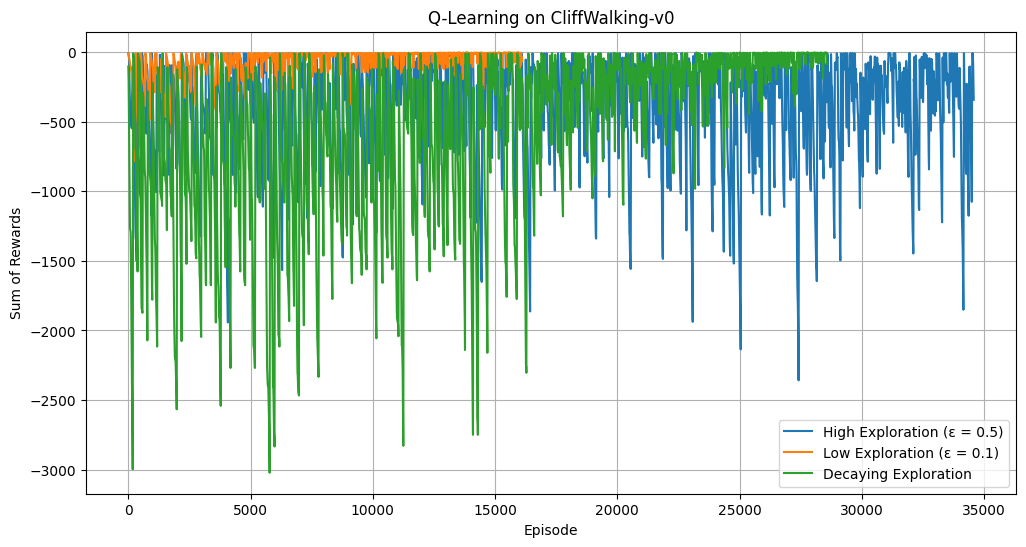

Plot saved as rewards_plot.png


In [42]:
plt.figure(figsize=(12, 6))

plt.plot(smooth_high, label="High Exploration (ε = 0.5)")
plt.plot(smooth_low, label="Low Exploration (ε = 0.1)")
plt.plot(smooth_decay, label="Decaying Exploration")

plt.xlabel("Episode")
plt.ylabel("Sum of Rewards")
plt.title("Q-Learning on CliffWalking-v0")

plt.legend()
plt.grid(True)

plt.savefig("rewards_plot.png")

plt.show()

print("Plot saved as rewards_plot.png")